In [1]:
## Packages Import
import numpy             as np
import matplotlib.pyplot as plt

In [ ]:
class VortexLatticeSolver:
    """
    Vortex lattice method
    """
    #--------------------#
    #   Initialization   #
    #--------------------#
    def __init__(self, b, c, lamb, delta, sym,
                n):
        # Wing geometry
        self.span     = b       # wing span                 [m]
        self.chord    = c       # chord lengths             [m]
        self.sweep    = lamb    # quarter-chord sweep angle [rad]
        self.dihedron = delta   # dihedral angle            [rad]
        self.symmetric = sym    # symmetric wing

        # Discretization
        self.N = n         # number of lattices
        self.c_4 = None    # quarter-chord points
        self.cp  = None    # control points
        self.cn  = None    # normal directions
        self.cv  = None    # direction of downwash velocities

    
    #-------------#
    #   Methods   #
    #-------------#
    def _unit_rot(self, v, theta, ax):
        """
        Elemental clockwise rotation of the reference system axes.
        
        v     -> vector componets - shape: (N, 3)
        theta -> rotation angle - clockwise rotation: theta>0
        ax    -> rotation axis index
        """
        # Assemble rotation matrix
        rot = np.zeros((3, 3))  # rotation matrix
        # diagonal elements
        rot[ax, ax] = 1.0
        rot[ax-1, ax-1] = np.cos(theta)
        rot[ax-2, ax-2] = np.cos(theta)
        # extra-diagonal elements
        rot[ax-2, ax-1] = -np.sin(theta)
        rot[ax-1, ax-2] = np.sin(theta)

        # Apply rotation
        v_rot = np.sum(rot[None, :, :] * v[:, None, :], axis=2)
        return v_rot
    

    def _build_mesh(self):
        """
        Discretization of the wing by a finite number of lattices.
        """
        n     = self.N
        b     = self.span
        c     = self.chord
        lamb  = self.sweep
        delta = self.dihedron

        if self.symmetric:
            s_min, s_max = 0.0, b/2
        else:
            s_min, s_max = -b/2, b/2

        # Spanwise wing discretization
        s = np.linspace(s_min, s_max, (n+1))

        # Express wing points in earth reference frame
        # Quarter-chord points
        c4_wing = np.column_stack(((0.25 * c), np.zeros(n+1), s))   # wing frame
        c4_dihed = self._unit_rot(c4_wing, lamb, 1)                 # dihedral frame
        c4_earth = self._unit_rot(c4_dihed, delta, 0)               # earth frame
        # Control points (three-quarter chord)
        cp_wing = np.column_stack(((0.75 * (0.5 *(c[1:] + c[:-1]))), np.zeros(n), (0.5 * (s[1:] + s[:-1]))))  # wing frame
        cp_dihed = self._unit_rot(cp_wing, lamb, 1)                                                           # dihedral frame
        cp_earth = self._unit_rot(cp_dihed, delta, 0)                                                         # earth frame
        # Normals to wing chamber line
        n_wing = np.column_stack((np.zeros(n), np.ones(n), np.zeros(n)))  # wing frame
        n_dihed = self._unit_rot(n_wing, lamb, 1)                         # dihedral frame
        n_earth = self._unit_rot(n_dihed, delta, 0)                       # earth frame

        self.c_4 = c4_earth
        self.cp  = cp_earth
        self.cn  = n_earth


In [ ]:
## Parameters Definition

# Wing geometry
B = 1.0         # wing span                 [m]
AR = 5.0        # aspect ration             [-]
L = 30.0        # quarter-chord sweep angle [deg]
D = -10.0       # dihedral angle            [deg]

SYM = True   # symmetric wing configuration

# Wing discretization
N = 4       # number of lattices

In [4]:
## Utilities

def chord_fn(n, c0, shape="rectangular"):
    """
    Return chord length distribution along spanwise direction according to the
    desired planform shape.
    """
    match shape:
        case "rectangular":
            c = c0 * np.ones(n)
        # case "elliptical":
        #     c = c0 * np.sqrt(1 - (z/s)**2)
    return c

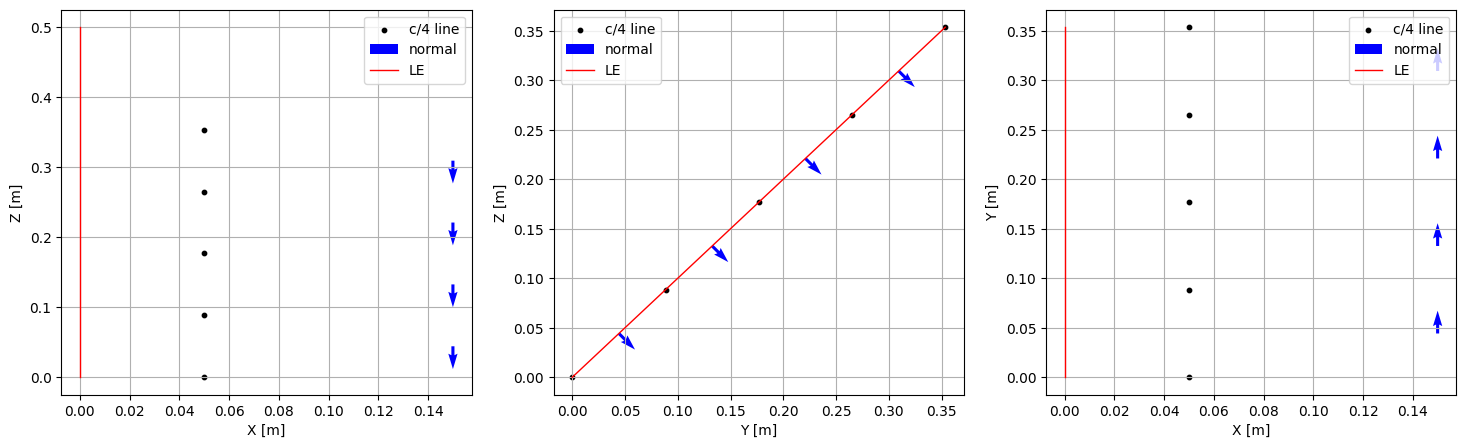

In [5]:
## TEST

# Untapered wing (constant chord length distribution)
c0 = B / AR     # chord length [m]

# Wing discretization and attitude
vlm = VortexLatticeSolver(b=B,
                        c=chord_fn((N+1), c0),
                        lamb=np.deg2rad(L),
                        delta=np.deg2rad(D),
                        sym=SYM,
                        n=N)
vlm._build_mesh()

p_plot = vlm.c_4
c_plot = vlm.cp
n_plot = vlm.cn

fig_test = plt.figure(figsize=(18, 5))
# Plot wing - lateral view
ax1 = fig_test.add_subplot(1, 3, 1)
ax1.scatter(p_plot[:, 0], p_plot[:, 2], c='k', s=10, label="c/4 line")
ax1.quiver(c_plot[:, 0], c_plot[:,2], n_plot[:, 0], n_plot[:, 2], color='b', label="normal")
ax1.plot([0, (B/2) * np.sin(np.deg2rad(L))], [0, (B/2) * np.cos(np.deg2rad(L))],
        color='r',
        linewidth=1,
        label="LE")
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Z [m]")
ax1.legend()
ax1.grid(True)
# Plot wing - frontal view
ax2 = fig_test.add_subplot(1, 3, 2)
ax2.scatter(p_plot[:, 1], p_plot[:, 2], c='k', s=10, label="c/4 line")
ax2.quiver(c_plot[:, 1], c_plot[:, 2], n_plot[:, 1], n_plot[:, 2], color='b', label="normal")
ax2.plot([0, -(B/2) * np.sin(np.deg2rad(D))], [0, (B/2) * np.cos(np.deg2rad(D))],
        color='r',
        linewidth=1,
        label="LE")
ax2.set_xlabel("Y [m]")
ax2.set_ylabel("Z [m]")
ax2.legend()
ax2.grid(True)
# Plot wing - frontal view
ax3 = fig_test.add_subplot(1, 3, 3)
ax3.scatter(p_plot[:, 0], p_plot[:, 1], c='k', s=10, label="c/4 line")
ax3.quiver(c_plot[:, 0], c_plot[:, 1], n_plot[:, 0], n_plot[:, 1], color='b', label="normal")
ax3.plot([0, (B/2) * np.sin(np.deg2rad(L))], [0, -(B/2) * np.sin(np.deg2rad(D))],
        color='r',
        linewidth=1,
        label="LE")
ax3.set_xlabel("X [m]")
ax3.set_ylabel("Y [m]")
ax3.legend()
ax3.grid(True)